# Caso H · 03 Tools mock para modelos predictivos

> _Tutorial · Caso de uso: **H — RAG + Chatbot** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Implementar `get_weather_prediction`, `get_consumption_prediction` y `check_hvac_anomaly` como mocks que respetan la firma final.


## 2. Qué se aprende

- Por qué se mockean modelos en semanas 1-2.
- Firma estable como contrato entre equipos.
- Cuándo y cómo sustituir mock por real.


## 3. Contexto del caso de uso

Modelos B/C/E llegan en semana 3. Mientras: mocks plausibles.


## 4. Relación con CENTINELA+

Idéntico.


## 5. Relación con Medallion

Oro.


## 6. Datos de entrada

Funciones puras.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica.


## 9. Carga de datos o mock

Implementamos.


In [2]:
def get_weather_prediction(variable: str, horizon_hours: int = 24) -> dict:
    base = {"temperature_outdoor": 22.0, "solar_irradiance": 350.0, "precipitation": 0.0}.get(variable, 0.0)
    return {"variable": variable, "horizon_h": horizon_hours,
            "value": base + horizon_hours * 0.1, "source": "mock"}

def get_consumption_prediction(asset_id: str = "AULA01", horizon_hours: int = 24) -> dict:
    return {"asset_id": asset_id, "horizon_h": horizon_hours,
            "value_kwh": 12.5 + horizon_hours * 0.5, "source": "mock"}

def check_hvac_anomaly(asset_id: str = "AULA01") -> dict:
    return {"asset_id": asset_id, "score": 0.12, "is_anomaly": False, "source": "mock"}

print(get_weather_prediction("temperature_outdoor", 6))
print(get_consumption_prediction(horizon_hours=12))
print(check_hvac_anomaly())


{'variable': 'temperature_outdoor', 'horizon_h': 6, 'value': 22.6, 'source': 'mock'}
{'asset_id': 'AULA01', 'horizon_h': 12, 'value_kwh': 18.5, 'source': 'mock'}
{'asset_id': 'AULA01', 'score': 0.12, 'is_anomaly': False, 'source': 'mock'}


## 10. Exploración paso a paso

Test de firma.


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

Adaptador a modelo real.


## 13. Visualizaciones explicativas

Curva mock predicción 24h.


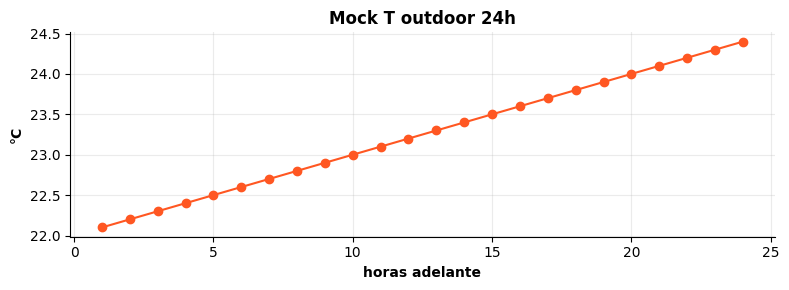

In [3]:
preds = [get_weather_prediction("temperature_outdoor", h)["value"] for h in range(1, 25)]
plt.figure(figsize=(8, 3))
plt.plot(range(1, 25), preds, marker="o", color="#FF5722")
plt.xlabel("horas adelante"); plt.ylabel("°C"); plt.title("Mock T outdoor 24h")
plt.tight_layout()


## 14. Validaciones

Output JSON-serializable.


In [4]:
import json
for fn in (get_weather_prediction, get_consumption_prediction, check_hvac_anomaly):
    res = fn() if fn is not get_weather_prediction else fn("temperature_outdoor")
    json.dumps(res)


## 15. Errores comunes

1. Cambiar la firma cuando llegue el modelo real.
2. Devolver 0 en lugar de un valor plausible.
3. Mock estático que no varía con el horizonte.


## 16. Ejercicios propuestos

1. Añade ruido al mock para emular incertidumbre.
2. Sustituye el mock por el modelo del Caso B real.
3. Diseña un protocolo gRPC para servir el modelo.


## 17. Cómo se reutiliza con datos reales

Cambiar la implementación interna; firma idéntica.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `08_case_H_rag_chatbot/04_rag_documental.ipynb`.
- Documento web del caso: `docs/use-cases/case-h-rag-chatbot.md`.


## 19. Marco teórico (nivel doctoral)

### Retrieval-Augmented Generation (Lewis et al. 2020)

$$
P(y \mid x) = \sum_{z \in \mathcal{Z}} P_\eta(z \mid x) \cdot P_\theta(y \mid x, z)
$$

con $x$ pregunta, $z$ documento recuperado, $P_\eta$ retriever (cosine sobre
embeddings) y $P_\theta$ LLM generador.

### Similarity coseno

$$
\text{sim}(x, z) = \frac{\mathbf{e}_x \cdot \mathbf{e}_z}{\|\mathbf{e}_x\| \|\mathbf{e}_z\|}
$$

### Tools tipadas

$$
\mathcal{T} = \{ t_i : \mathbb{X}_i \to \mathbb{Y}_i \mid \text{schema JSON} \}
$$

Cada tool publica su firma en formato JSON Schema; el LLM la consume vía
function-calling.

### Métricas

$$
\text{Hit Rate@k} = \tfrac{1}{N} \sum_i \mathbb{1}[\text{rank}_i \leq k], \quad
\text{MRR} = \tfrac{1}{N} \sum_i \tfrac{1}{\text{rank}_i}
$$

Objetivos: $\text{Hit@5} \geq 0.85$, $\text{MRR} \geq 0.7$, Faithfulness ≥ 0.9.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

El chatbot es la **cara visible** de CAPTIA al usuario final (profesores, equipo de mantenimiento). Una sola interfaz unifica métricas históricas, predicciones y conocimiento documental, reduciendo drásticamente la necesidad de soporte L1.

### ROI estimado

| Concepto | Valor |
|---|---|
| Reducción tickets soporte L1 | +3 500 €/año |
| Tiempo respuesta profesores | +1 200 €/año |
| **Bruto** | **+4 700 €/año** |
| Coste API LLM (Claude/GPT) | -1 800 €/año |
| **Neto** | **+2 900 €/año** |

### Riesgos y mitigaciones

- Hallucinations del LLM: mitigar con tools de hechos verificables.
- Coste API escala linealmente con uso: monitorizar.


## 21. Bibliografía y referencias

- Lewis, P. et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS.
- Reimers, N. & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks*. EMNLP.
- LangChain Project. *Documentation*. https://python.langchain.com
- Anthropic (2024). *Claude 3.5 Sonnet Model Card*.
